In [4]:
!pip install pandas numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 31.2 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 36.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [7]:
!pip install openpyxl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [6]:
import subprocess, sys
def install(p): subprocess.check_call([sys.executable, "-m", "pip", "install", p])
for p in ["pandas","numpy","openpyxl"]:
    try: __import__(p)
    except: install(p)

import pandas as pd
import numpy as np

# Load data
df = pd.read_excel("data.xlsx")

# Rename columns (chỉnh lại đúng tên file bạn)
df = df.rename(columns={
    "Year": "year",
    "TF": "TFR",
    "GDP": "GDP",
    "LF": "LF",
    "Hexp": "Health"
})

# Transform
df["ln_GDP"] = np.log(df["GDP"])

# Policy dummy (1993 shock)
df["policy"] = (df["year"] >= 1993).astype(int)

# Save cleaned data
df.to_csv("data_clean.csv", index=False)

desc = df.describe()
desc.to_csv("descriptive_stats.csv")

print(desc)

              year     Policy     Health          GDP         LF        TFR  \
count    39.000000  39.000000  24.000000    39.000000  34.000000  39.000000   
mean   2004.000000   0.794872   4.577700  1354.732919  49.321037   2.418923   
std      11.401754   0.409074   0.352477  1323.576522   0.484366   0.725683   
min    1985.000000   0.000000   3.870759    98.107017  48.097193   1.873000   
25%    1994.500000   1.000000   4.353262   361.497406  49.108266   1.937500   
50%    2004.000000   1.000000   4.565447   595.247489  49.423922   2.000000   
75%    2013.500000   1.000000   4.895979  2452.951005  49.604674   2.820500   
max    2023.000000   1.000000   5.071461  4323.350320  50.044826   4.206000   

          ln_GDP     policy  
count  39.000000  39.000000  
mean    6.647702   0.794872  
std     1.144869   0.409074  
min     4.586059   0.000000  
25%     5.890255   1.000000  
50%     6.388977   1.000000  
75%     7.804321   1.000000  
max     8.371786   1.000000  


In [11]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 37.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 46.0 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [13]:
import pandas as pd
import statsmodels.api as sm

# Load data
df = pd.read_csv("data_clean.csv")

# Filter
df1 = df[df["year"] >= 1990]

# Define variables
X = df1[["Policy", "ln_GDP", "LF"]]
X = sm.add_constant(X)

y = df1["TFR"]

# OLS regression
model1 = sm.OLS(y, X).fit()

print(model1.summary())

# Save results
with open("omodel1.txt", "w") as f:
    f.write(model1.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:                    TFR   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     35.56
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           5.28e-10
Time:                        15:17:34   Log-Likelihood:                 1.3665
No. Observations:                  34   AIC:                             5.267
Df Residuals:                      30   BIC:                             11.37
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6893     10.338      0.260      0.7

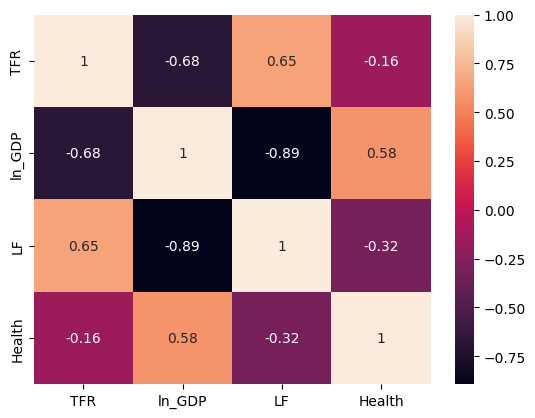

In [10]:
# ==== AUTO INSTALL ====
import subprocess, sys
def install(p): subprocess.check_call([sys.executable, "-m", "pip", "install", p])
for p in ["pandas","matplotlib","seaborn"]:
    try: __import__(p)
    except: install(p)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data_clean.csv")

# ==== CORRELATION MATRIX ====
corr = df[["TFR","ln_GDP","LF","Health"]].corr()
corr.to_csv("correlation_matrix.csv")

sns.heatmap(corr, annot=True)
plt.savefig("correlation.png")
plt.show()




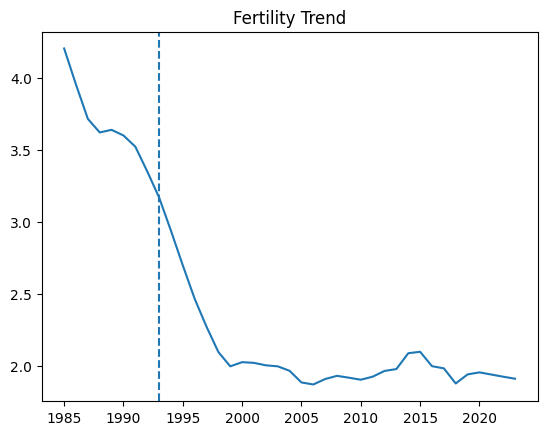

In [11]:
# ==== TREND ====
plt.plot(df["year"], df["TFR"])
plt.axvline(x=1993, linestyle="--")
plt.title("Fertility Trend")
plt.savefig("tfr_trend.png")
plt.show()

In [2]:
# ==== AUTO INSTALL ====
import subprocess, sys
def install(p): subprocess.check_call([sys.executable, "-m", "pip", "install", p])
for p in ["pandas","statsmodels","numpy"]:
    try: __import__(p)
    except: install(p)

import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller
import numpy as np

df = pd.read_csv("data_clean.csv")
df1 = df[df["year"] >= 1990]

# ==== VARIABLES ====
X = df1[["policy","ln_GDP","LF"]]
X = sm.add_constant(X)
y = df1["TFR"]

# ==== OLS ====
model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())

# ==== SAVE RESULT ====
with open("model1.txt","w") as f:
    f.write(model.summary().as_text())

# ==== VIF ====
vif = pd.DataFrame()
vif["var"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif.to_csv("vif.csv")

# ==== HETEROSKEDASTICITY ====
bp_test = het_breuschpagan(model.resid, X)
print("Breusch-Pagan:", bp_test)

# ==== AUTOCORRELATION ====
dw = durbin_watson(model.resid)
print("Durbin-Watson:", dw)

# ==== STATIONARITY ====
adf = adfuller(df1["TFR"])
print("ADF test:", adf)

                            OLS Regression Results                            
Dep. Variable:                    TFR   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     133.4
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           1.95e-17
Time:                        06:19:30   Log-Likelihood:                 1.3665
No. Observations:                  34   AIC:                             5.267
Df Residuals:                      30   BIC:                             11.37
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6893      7.108      0.378      0.7

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                    TFR   No. Observations:                   24
Model:               SARIMAX(1, 1, 1)   Log Likelihood                  38.171
Date:                Wed, 01 Apr 2026   AIC                            -64.341
Time:                        06:20:51   BIC                            -57.528
Sample:                             0   HQIC                           -62.628
                                 - 24                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ln_GDP        -0.0680      0.131     -0.520      0.603      -0.325       0.189
LF            -0.0415      0.135     -0.308      0.758      -0.305       0.222
Health         0.0022      0.066      0.033      0.9

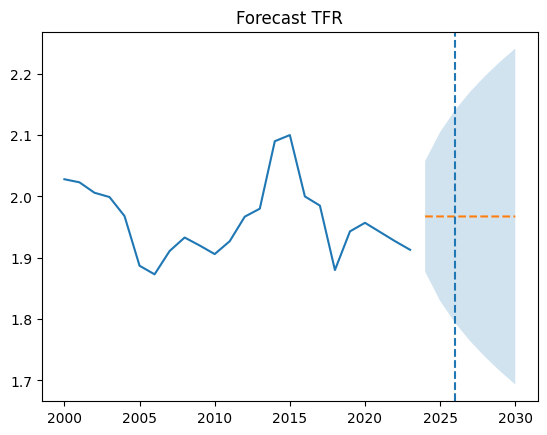

In [3]:
# ==== AUTO INSTALL ====
import subprocess, sys
def install(p): subprocess.check_call([sys.executable, "-m", "pip", "install", p])
for p in ["pandas","statsmodels","matplotlib","numpy"]:
    try: __import__(p)
    except: install(p)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

df = pd.read_csv("data_clean.csv")
df2 = df[df["year"] >= 2000]

# ==== TIME SERIES ====
y = df2["TFR"]
exog = df2[["ln_GDP","LF","Health"]]

# ==== MODEL ====
model = SARIMAX(y, exog=exog, order=(1,1,1))
results = model.fit()

print(results.summary())

# ==== FORECAST ====
future_years = list(range(2024,2031))

future_exog = pd.DataFrame({
    "ln_GDP":[exog["ln_GDP"].mean()]*len(future_years),
    "LF":[exog["LF"].mean()]*len(future_years),
    "Health":[exog["Health"].mean()]*len(future_years)
})

forecast = results.get_forecast(steps=len(future_years), exog=future_exog)

pred = forecast.predicted_mean
conf = forecast.conf_int()

# ==== PLOT ====
plt.figure()
plt.plot(df2["year"], y)
plt.plot(future_years, pred, linestyle="--")

plt.fill_between(future_years,
                 conf.iloc[:,0],
                 conf.iloc[:,1],
                 alpha=0.2)

plt.axvline(x=2026, linestyle="--")
plt.title("Forecast TFR")

plt.savefig("forecast.png")
plt.show()

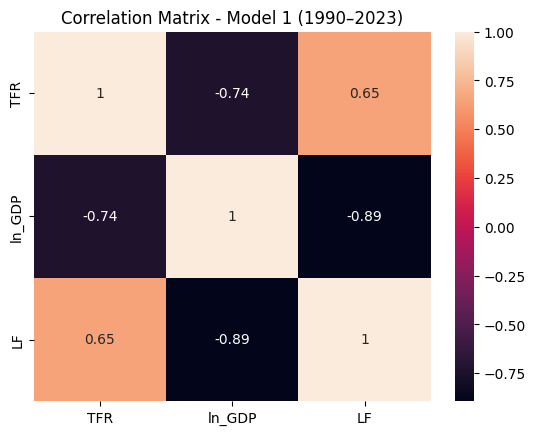

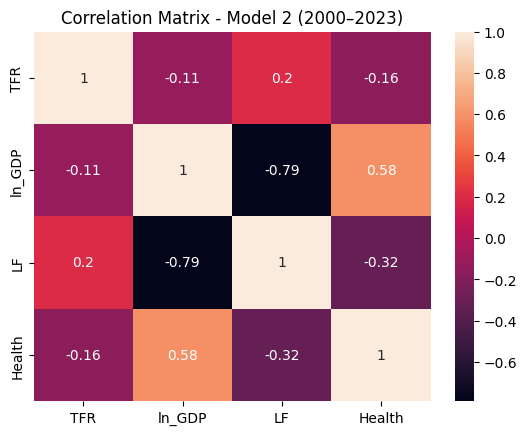

In [3]:
# ==== AUTO INSTALL ====
import subprocess, sys
def install(p): subprocess.check_call([sys.executable, "-m", "pip", "install", p])
for p in ["pandas","matplotlib","seaborn"]:
    try: __import__(p)
    except: install(p)

# ==== IMPORT ====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==== LOAD DATA ====
df = pd.read_csv("data_clean.csv")

# ==============================
# MODEL 1: 1990–2023 (NO HEALTH)
# ==============================
df1 = df[df["year"] >= 1990]

corr1 = df1[["TFR", "ln_GDP", "LF"]].corr()

# Save table
corr1.to_csv("corr_model1.csv")

# Plot heatmap
plt.figure()
sns.heatmap(corr1, annot=True)
plt.title("Correlation Matrix - Model 1 (1990–2023)")
plt.savefig("corr_model1.png")
plt.show()


# ==============================
# MODEL 2: 2000–2023 (WITH HEALTH)
# ==============================
df2 = df[df["year"] >= 2000]

corr2 = df2[["TFR", "ln_GDP", "LF", "Health"]].corr()

# Save table
corr2.to_csv("corr_model2.csv")

# Plot heatmap
plt.figure()
sns.heatmap(corr2, annot=True)
plt.title("Correlation Matrix - Model 2 (2000–2023)")
plt.savefig("corr_model2.png")
plt.show()

